In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cor_da_justica.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2798 entries, 0 to 2797
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             2798 non-null   int64  
 1   ementa                 2798 non-null   object 
 2   ementaDetalhada        412 non-null    object 
 3   keywords               2749 non-null   object 
 4   uris.uriAutores        2798 non-null   object 
 5   uris.uriPropPrincipal  1220 non-null   object 
 6   uris.uriUltimoRelator  1598 non-null   object 
 7   nome                   2798 non-null   object 
 8   cpf                    2798 non-null   int64  
 9   foto                   2798 non-null   object 
 10  sexo                   2798 non-null   object 
 11  nascimento             2798 non-null   object 
 12  local_nascimento       2798 non-null   object 
 13  escolaridade           2750 non-null   object 
 14  orgão                  0 non-null      float64
 15  emen

In [4]:
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "ementaDetalhada", "ementa.1", "keywords.1", "cpf", ]

In [5]:
df = df.drop(columns=remover_colunas)

In [6]:
df

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
0,Dispõe sobre a obrigatoriedade de fotografia n...,"Alteração, Lei do Processamento Eletrônico do ...",CARLOS FREDERICO THEODORO NADER,M,1965-09-21,Barra Mansa - RJ,Superior,NaN,NaN,NaN,#NE
1,Garante ao acertador de qualquer tipo de jogo ...,"Garantia, omissão, identificação, ganhador, lo...",ANDRES NAVARRO SANCHEZ,M,1963-12-24,Limeira - SP,Ensino Fundamental,NaN,Aguardando Parecer,Projeto de Lei,BRANCA
2,Dispõe sobre a obrigatoriedade das prestadoras...,"Obrigatoriedade, concessionária, telefone celu...",FRANCISCO RODRIGUES DE ALENCAR FILHO,M,1949-10-19,Rio de Janeiro - RJ,Mestrado,NaN,Aguardando Parecer,Projeto de Lei,#NE
3,Institui o dia 02 de julho como data histórica...,"Criação, Dia Nacional da Independência do Bras...",DOUGLAS DE PAULO VIEGAS,M,1979-06-19,São Paulo - SP,NaN,NaN,NaN,NaN,PARDA
4,Altera o inciso I do § 1º do art. 68 da Lei nº...,"Alteração, Nova Lei de Patentes, licenciament...",CÁSSIO MURILO GALDINO DE ARAÚJO,M,1980-07-02,Pocinhos - PB,Superior,NaN,NaN,NaN,BRANCA
...,...,...,...,...,...,...,...,...,...,...,...
2793,"Altera a Lei nº 4.375, de 1964, dispondo sobre...","Alteração, Lei do Serviço Militar, critério, s...",LUCIANO LORENZINI ZUCCO,M,1974-03-09,Alegrete - RS,Mestrado,NaN,NaN,NaN,BRANCA
2794,"Obriga a manutenção, reinscrição ou disponibil...","Obrigatoriedade, manutenção, reinclusão, infor...",FLÁVIO RODRIGUES NOGUEIRA,M,1953-02-27,Alto Santo - CE,Superior,NaN,NaN,NaN,#NE#
2795,"Acrescenta ao Código de Defesa do Consumidor, ...","Alteração, Código de Defesa do Consumidor, sus...",PEDRO AUGUSTO GEROMEL BEZERRA DE MENEZES,M,1980-10-11,Juazeiro do Norte - CE,Pós-Graduação,NaN,Aguardando Parecer,Projeto de Lei,BRANCA
2796,Institui a proibição de que estabelecimentos c...,"Proibição, estabelecimento comercial, fabrican...",JOSE MARIO SCHREINER,M,1961-02-08,Porto União - SC,Ensino Técnico,NaN,Tramitando em Conjunto,Projeto de Lei,BRANCA


In [7]:
df_corr = df.drop(columns=["ementa","keywords", "nome", "nascimento", "local_nascimento", "escolaridade", "orgão","cor"]).reset_index(drop=True)

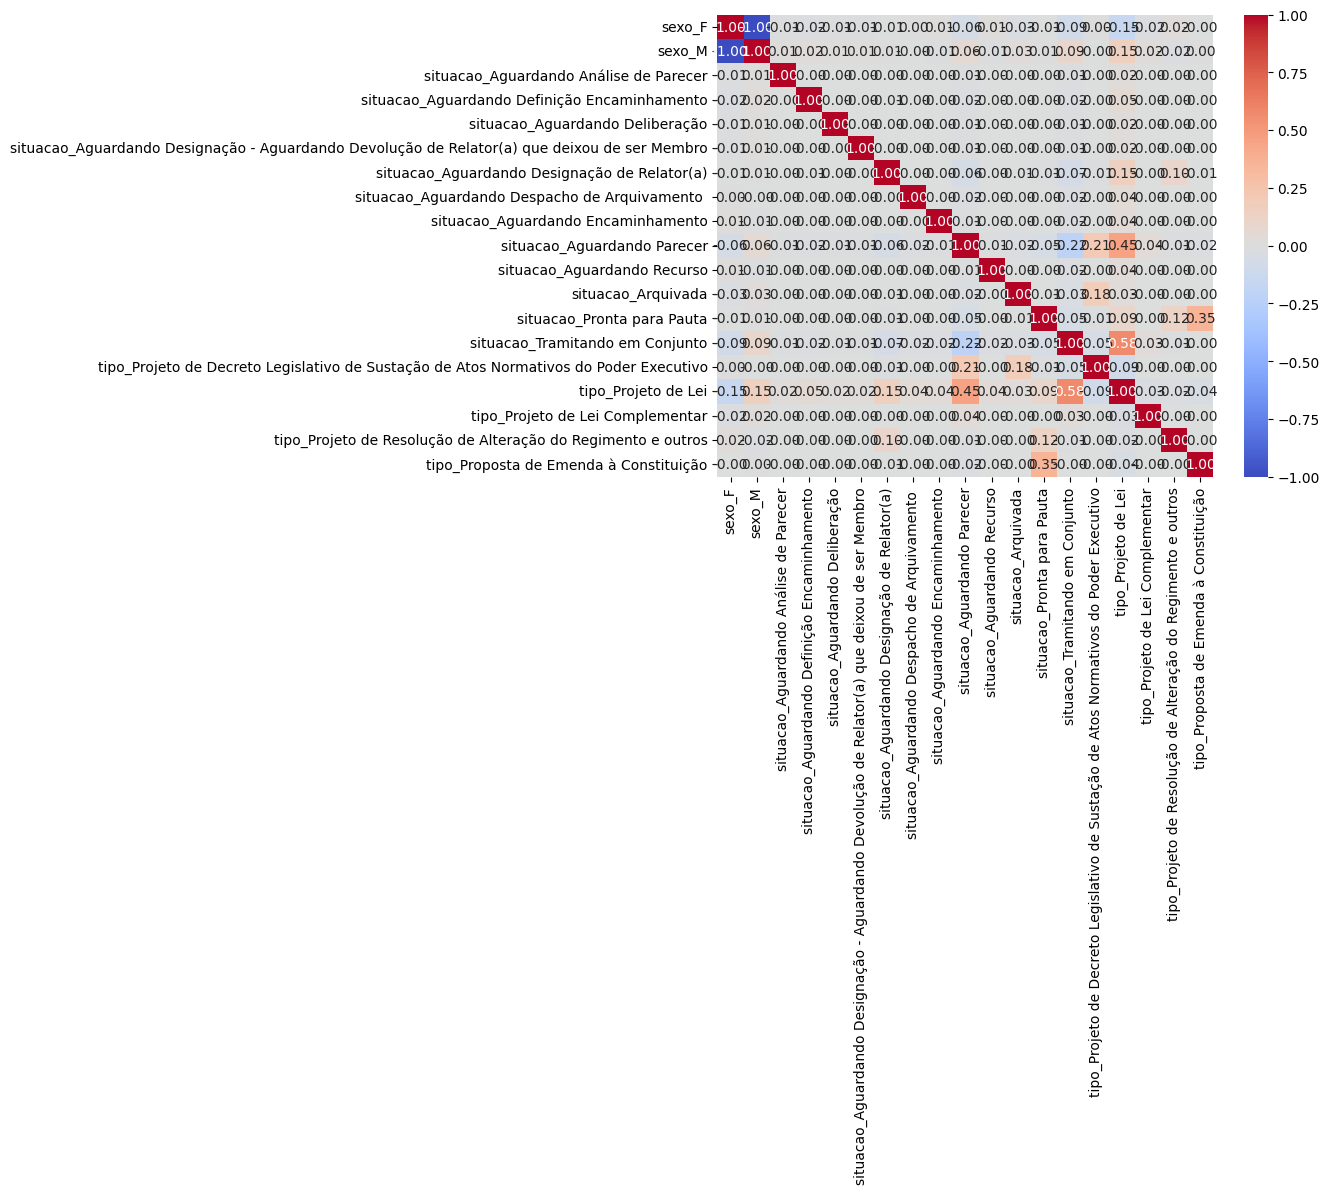

In [8]:
# Suponha que 'df' seja seu DataFrame original com variáveis categóricas
# Converta variáveis categóricas em variáveis dummy
df_dummies = pd.get_dummies(df_corr)

# Calcule a matriz de correlação
corr_matrix = df_dummies.corr()

# Exiba o heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [9]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"

C:\Users\alexa\AppData\Local\Temp\ipykernel_17140\979912387.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["s

In [10]:
situacao = df["situacao"].value_counts().reset_index()

In [11]:
situacao

,situacao,count
0,TRAMITANDO,585
1,AGUARDANDO,521


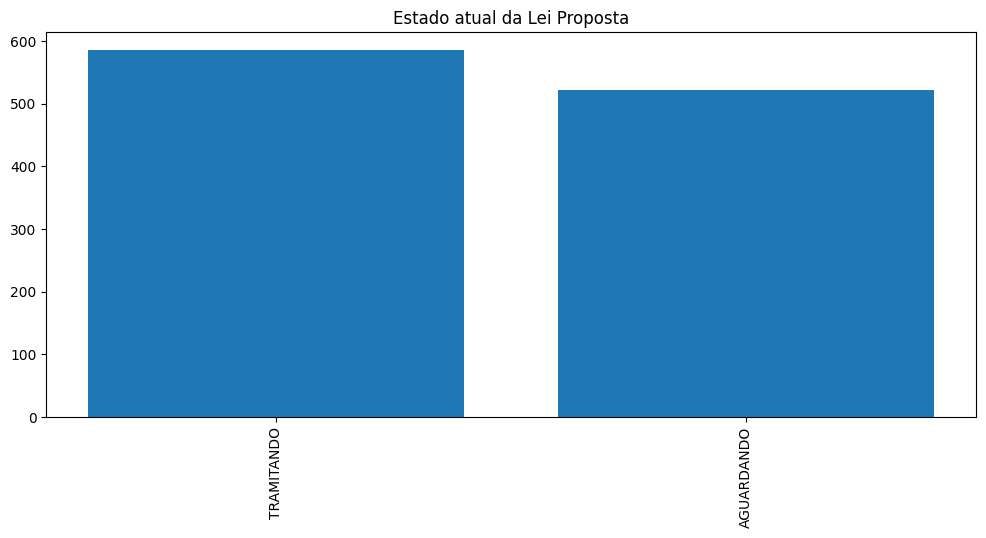

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

ax.bar(situacao["situacao"], height=situacao["count"],)
plt.xticks(rotation=90)
# plt.bar()
ax.set_title("Estado atual da Lei Proposta")
plt.show()

In [13]:
sexo = df['sexo'].value_counts().reset_index()

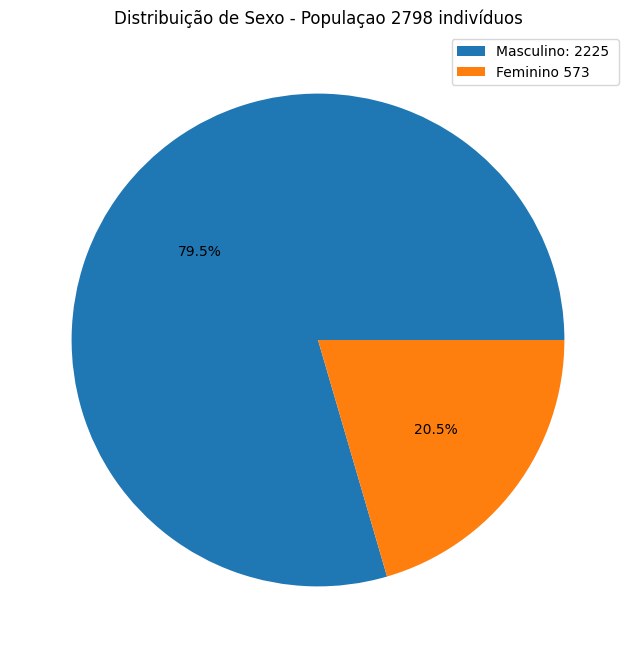

In [14]:
fg, ax = plt.subplots(1, 1, figsize=(12, 8))

ax.pie(sexo["count"], autopct="%.1f%%")
ax.set_title(
    f"Distribuição de Sexo - Populaçao {df['sexo'].count()} indivíduos")
ax.legend([f"Masculino: {sexo['count'][0]} ", f"Feminino {sexo['count'][1]}"])
plt.show()

In [15]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

In [16]:
df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA")] = "OUTROS"

C:\Users\alexa\AppData\Local\Temp\ipykernel_17140\2265721978.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df["cor"].loc[(df["cor"] == "AMARELA") | (
C:\Users\alexa\AppData\Local\Temp\ipykernel_17140\2265721978.py:1: SettingWithCopyWar

In [17]:
cor = df["cor"].value_counts().reset_index()

In [18]:
cor["cor"].unique()
cor

,cor,count
0,BRANCA,769
1,PARDA,236
2,PRETA,26
3,OUTROS,24


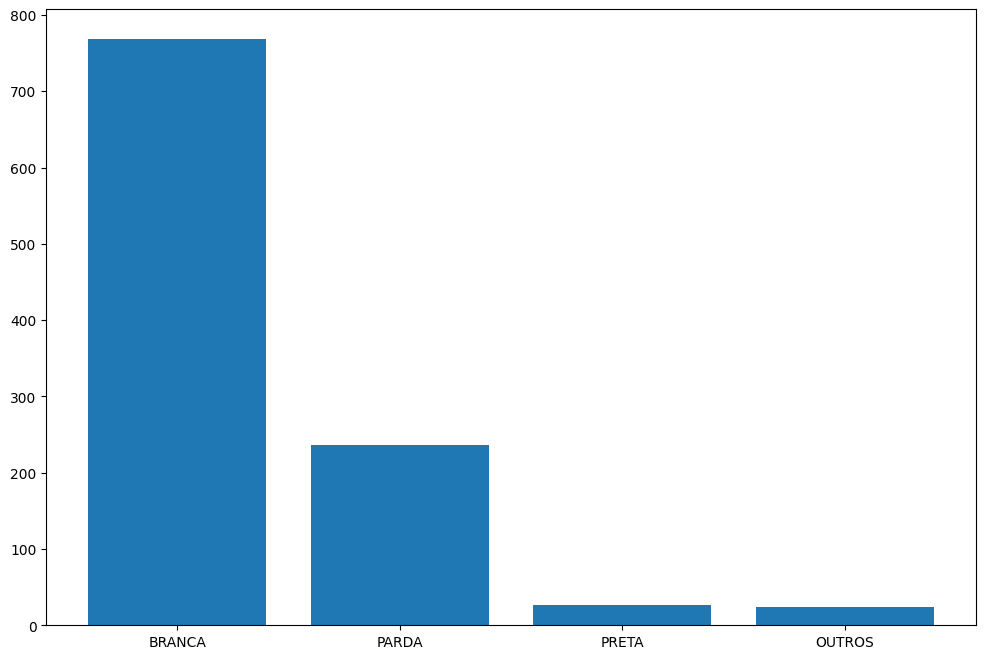

In [19]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [20]:
df.iloc[10:50]

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
10,Dispõe sobre a reintegração no emprego dos fun...,"Garantia, reintegração, retorno, emprego, ex-f...",FERNANDO MONTEIRO DE ALBUQUERQUE,M,1976-09-17,Recife - PE,Superior,NaN,NaN,NaN,BRANCA
11,"Altera as Leis nºs 8.429, de 2 de junho de 19...","Alteração, Lei da Improbidade Administrativa, ...",KIM PATROCA KATAGUIRI,M,1996-01-28,Salto - SP,Superior Incompleto,NaN,NaN,NaN,OUTROS
12,Autoriza o Poder Executivo a criar o Programa ...,"Autorização, Executivo, criação, Programa de I...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,NaN,NaN,BRANCA
13,"Altera a Lei nº 9.656, de 3 de junho de 1998, ...","Alteração, Lei dos Planos de Saúde, cobertura,...",HILDELIS SILVA DUARTE JUNIOR,M,1986-09-15,Rio de Janeiro - RJ,Doutorado Incompleto,NaN,NaN,NaN,BRANCA
14,Dispõe sobre o Estatuto do Nascituro e dá outr...,"Criação, Estatuto do Nascituro, proteção, nasc...",PRISCILA BEZERRA DA COSTA,F,1984-09-12,Fortaleza - CE,Superior,NaN,NaN,NaN,PARDA
15,"Altera a Lei nº 5.991, de 17 de setembro de 19...","Alteração, Lei de Controle Sanitário de Medica...",ALESSANDRA HABER CARVALHO SANTOS,F,1988-09-15,Belém - PA,Superior,NaN,NaN,NaN,BRANCA
16,Dá nova redação ao § 4º do art. 201 da Constit...,"Previdência Social, vinculação, reajuste, valo...",SAMIA DE SOUZA BOMFIM,F,1989-08-22,Presidente Prudente - SP,Superior,NaN,NaN,NaN,BRANCA
17,"Revoga a Lei Complementar nº 110, de 29 de jun...","Revogação, Lei de Atualização Monetária do FG...",RODRIGO SANTANA VALADARES,M,1989-08-06,Aracaju - SE,Superior,NaN,NaN,NaN,BRANCA
18,"Dispõe sobre a prática de tatuagem e ""piercing"".","Funcionamento, estabelecimento comercial, prof...",LUIZ EDUARDO CARNEIRO DA SILVA DE SOUZA LIMA,M,1977-12-10,Rio de Janeiro - RJ,Superior,NaN,NaN,NaN,PARDA
19,Dispõe sobre a obrigatoriedade de banheiros pú...,"Obrigatoriedade, agência bancária, instalação,...",DANIELA MOTE DE SOUZA CARNEIRO,F,1976-02-10,Rio de Janeiro - RJ,Pós-Graduação,NaN,NaN,NaN,BRANCA


In [21]:
df.iloc[38:39]

,ementa,keywords,nome,sexo,nascimento,local_nascimento,escolaridade,orgão,situacao,tipo,cor
38,Dispõe sobre a instalação e o funcionamento do...,"Autorização, Poder Executivo, criação, Banco d...",RUBIA FERNANDA DINIZ ROBSON SANTOS DE SIQUEIRA,F,1974-11-13,Cuiabá - MT,Superior,NaN,NaN,NaN,OUTROS


In [22]:
from nltk.stem import PorterStemmer
import nltk
from nltk.corpus import stopwords

# stopwords = nltk.download('stopwords')
stemmer = PorterStemmer()

## TF - IDF


In [23]:

from sklearn.feature_extraction.text import TfidfVectorizer

tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,2) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()

In [24]:
vocab

array(['00', '00 br', '001', ..., 'único programas', 'único referido',
       'único saúde'], dtype=object)

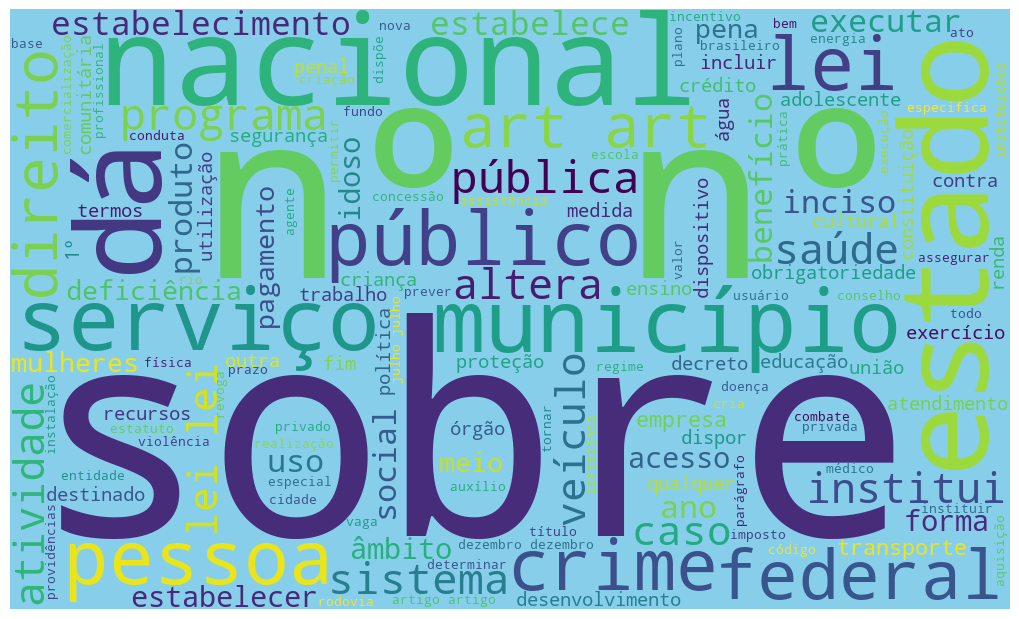

In [25]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud
vocab = ' '.join(vocab)

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='skyblue',
    min_font_size=10).generate(vocab)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [26]:
X

<1055x16302 sparse matrix of type '<class 'numpy.float64'>'
	with 37976 stored elements in Compressed Sparse Row format>

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])

In [28]:
y = df["cor"]

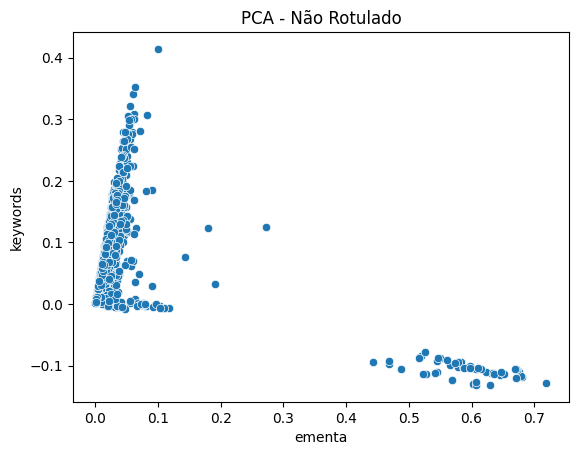

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=3)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'keywords', 'cor',])


# Visualize the transformed data

sns.scatterplot(x='ementa', y="keywords", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

In [30]:
df["cor"]

0       0
1       2
2       0
3       0
4       0
       ..
1050    0
1051    0
1052    0
1053    0
1054    0
Name: cor, Length: 1055, dtype: int32

In [31]:
df_pca["cor"]

0      -0.004011
1      -0.012055
2       0.013339
3      -0.014267
4       0.039888
          ...   
1050   -0.062573
1051    0.008997
1052    0.023226
1053   -0.041595
1054   -0.010982
Name: cor, Length: 1055, dtype: float64

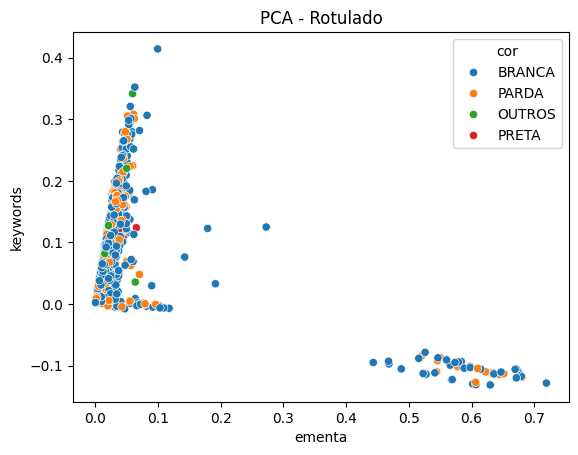

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA, TruncatedSVD
import pandas as pd

# Instantiate the PCA model with the desired number of components
# In this example, we set n_components to 2 for 2D visualization
pca = TruncatedSVD(n_components=3)

# Fit the PCA model and transform the data
X_pca = pca.fit_transform(X)

# Create a DataFrame for visualization purposes
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'keywords', 'cor',])

y_map = {0: 'BRANCA', 1: "OUTROS",  2: 'PARDA',  3: 'PRETA'}


df_pca["cor"] = df["cor"].map(y_map)

# Visualize the transformed data

sns.scatterplot(x='ementa', y="keywords", hue="cor", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

# Treinar Modelo


In [33]:
df["cor"].value_counts()

cor
0    769
2    236
3     26
1     24
Name: count, dtype: int64

In [34]:
df["cor"].unique()

array([0, 2, 1, 3])

In [35]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [36]:
X_train

<844x16302 sparse matrix of type '<class 'numpy.float64'>'
	with 30249 stored elements in Compressed Sparse Row format>

In [37]:
# Creating a function to display model results
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    # t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
    #                             "Amarela", "Branca", "Indígena", "ND", "Parda", "Negra"])
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros", "Pardas", "Negras"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

# Logistic Regression


In [38]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LogisticRegression(
    random_state=42, max_iter=1000, solver="lbfgs", penalty="l2", C=1, tol=0.0001)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.74407583 0.69668246 0.69668246 0.7014218  0.8056872 ]
Mean F1 Score: 0.7289099526066352


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.74      1.00      0.85       157
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00        41
           3       0.00      0.00      0.00         8

    accuracy                           0.74       211
   macro avg       0.19      0.25      0.21       211
weighted avg       0.55      0.74      0.63       211



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

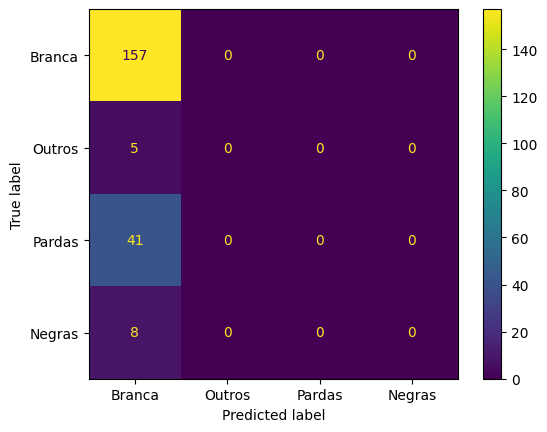

In [39]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

In [40]:
y_train

321     0
758     0
442     0
362     2
377     0
       ..
330     0
466     0
121     0
1044    2
860     0
Name: cor, Length: 844, dtype: int32

# SGD Classifier


In [41]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier  # Replace with your model

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = SGDClassifier(random_state=42, alpha=0.0001, )

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.73933649 0.68720379 0.68720379 0.67772512 0.76303318]
Mean F1 Score: 0.7109004739336493


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.97      0.85       157
           1       0.00      0.00      0.00         5
           2       0.38      0.07      0.12        41
           3       0.00      0.00      0.00         8

    accuracy                           0.74       211
   macro avg       0.28      0.26      0.24       211
weighted avg       0.63      0.74      0.66       211



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

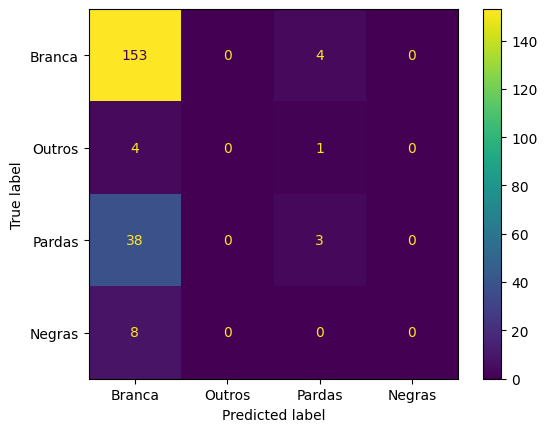

In [42]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# KNeighbors Classifier


In [43]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
# You can adjust the number of neighbors
model = KNeighborsClassifier(
    n_neighbors=1, weights="uniform", algorithm="brute", leaf_size=30, p=2)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.63033175 0.60189573 0.58767773 0.60663507 0.58293839]
Mean F1 Score: 0.6018957345971564


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.76      0.77       157
           1       0.20      0.20      0.20         5
           2       0.24      0.27      0.25        41
           3       0.25      0.12      0.17         8

    accuracy                           0.63       211
   macro avg       0.36      0.34      0.35       211
weighted avg       0.63      0.63      0.63       211



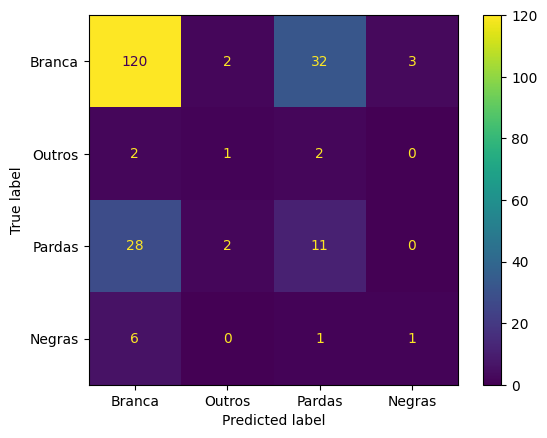

In [44]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

evaluation_parametrics("Machine Learning - KNN", y_test, y_pred)

# SVC


In [45]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.svm import LinearSVC
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = LinearSVC(penalty="l2", loss='squared_hinge',
                  tol=0.000001, C=10, multi_class='ovr', dual=True)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.74407583 0.68720379 0.67772512 0.68246445 0.77251185]
Mean F1 Score: 0.7127962085308057


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.98      0.85       157
           1       0.00      0.00      0.00         5
           2       0.43      0.07      0.12        41
           3       0.00      0.00      0.00         8

    accuracy                           0.74       211
   macro avg       0.30      0.26      0.24       211
weighted avg       0.64      0.74      0.66       211



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

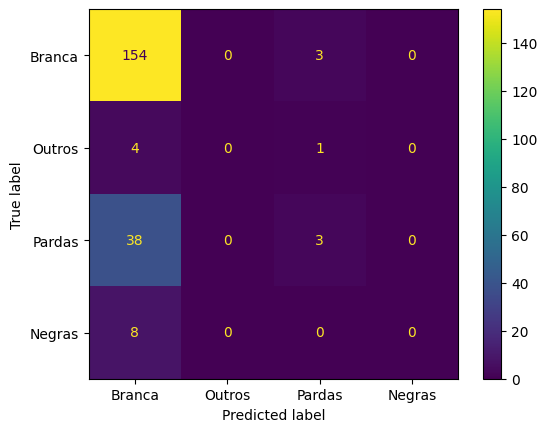

In [46]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest


In [47]:

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
# K is the number of folds
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Replace 'LogisticRegression()' with your specific model instantiation
model = RandomForestClassifier(
    n_estimators=100, criterion='log_loss', max_depth=None, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
# Replace 'f1_micro' with your desired metric
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')


# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

Cross-Validation Results: [0.72985782 0.69668246 0.69668246 0.69668246 0.8056872 ]
Mean F1 Score: 0.7251184834123222


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.74      0.97      0.84       157
           1       0.00      0.00      0.00         5
           2       0.00      0.00      0.00        41
           3       0.00      0.00      0.00         8

    accuracy                           0.73       211
   macro avg       0.18      0.24      0.21       211
weighted avg       0.55      0.73      0.63       211



c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\alexa\Desktop\OsCrias\crawler-api\venv\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap

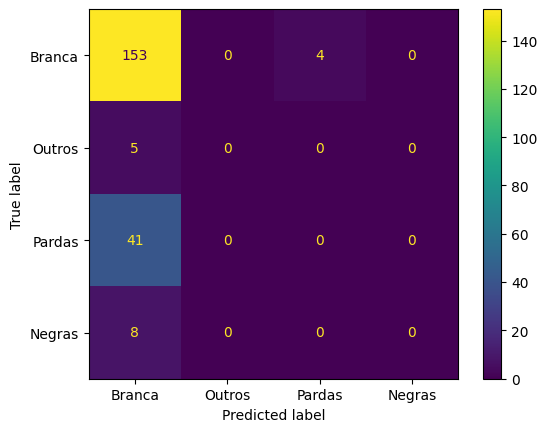

In [48]:
# Visualizing model results
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree


Cross-Validation Results: [0.65876777 0.63507109 0.61137441 0.65876777 0.67298578]
Mean F1 Score: 0.6473933649289101


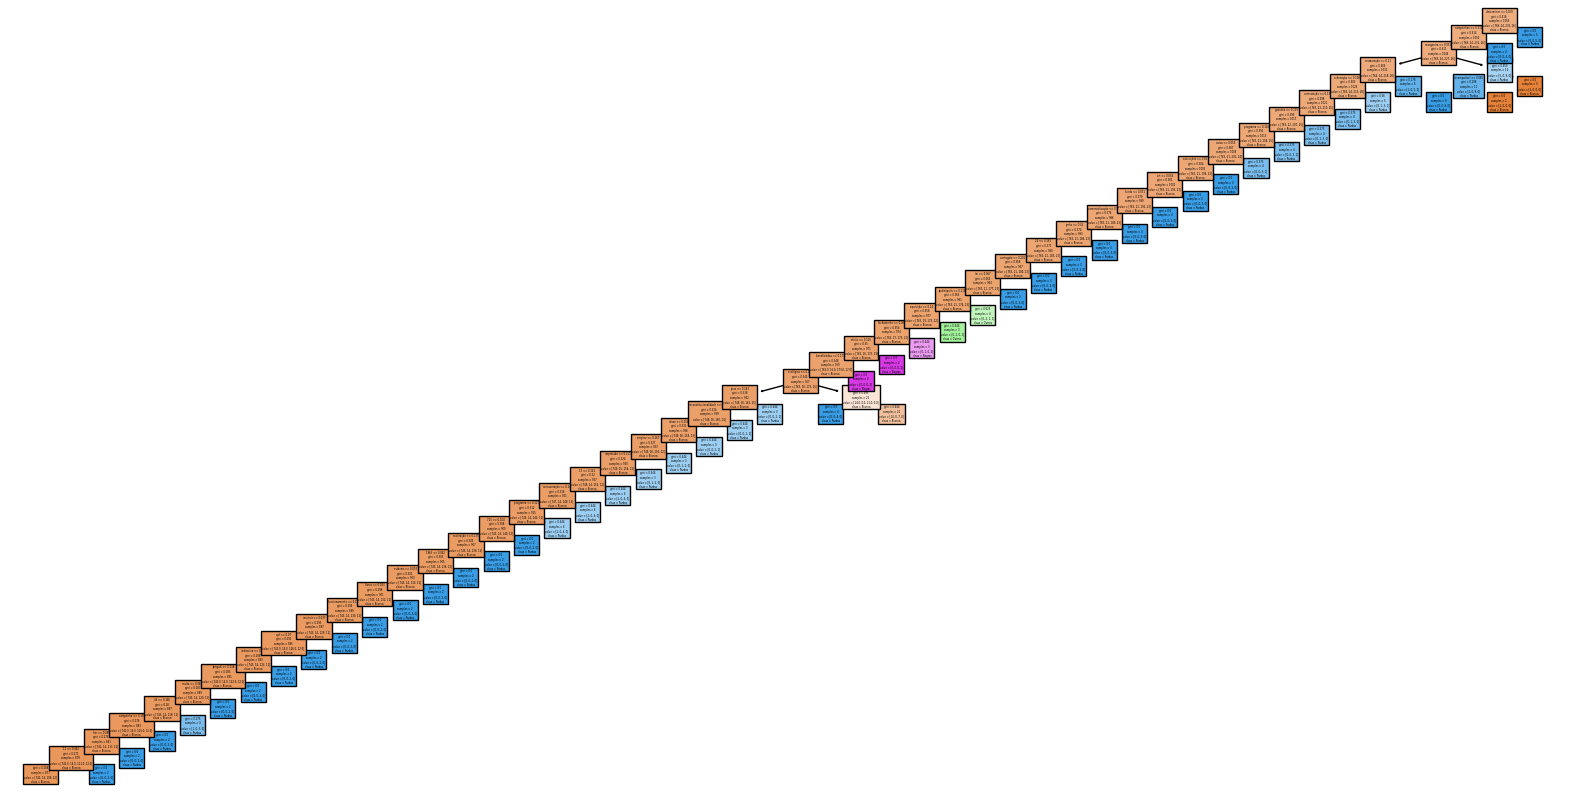

In [49]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Assuming 'X' is your feature matrix and 'y' is your target variable
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Create the decision tree classifier
model = DecisionTreeClassifier(max_leaf_nodes=50, random_state=42)

# Use cross_val_score to perform K-Fold cross-validation
cross_val_results = cross_val_score(model, X, y, cv=kf, scoring='f1_micro')

# Print the cross-validation results
print("Cross-Validation Results:", cross_val_results)
print("Mean F1 Score:", cross_val_results.mean())

# Fit the decision tree classifier on the entire dataset
model.fit(X, y)
# Plot the decision tree
plt.figure(figsize=(20, 10))  # Adjust the figure size as needed
plot_tree(model,  feature_names=vocab.split(), class_names=["Branca", "Outros", "Pardas", "Negras"], filled=True)

plt.show()
